# Laboratorio integrador: analizador de tendencias en noticias argentinas

**Duración estimada:** 1 hora

## Desafío
Vas a construir un sistema en Python que extraiga noticias de la web y las procese con `spaCy` para identificar entidades, verbos frecuentes, palabras clave y visualizaciones básicas.

## Resultados esperados
Al finalizar este laboratorio, vas a poder:
- extraer texto desde una URL periodística;
- encapsular análisis lingüístico en una clase reutilizable;
- generar visualizaciones a partir del texto procesado;
- integrar varias piezas en un pipeline simple de análisis de noticias.

## Modalidad de trabajo: pair programming con IA
En esta cátedra, `pair programming con IA` significa que la unidad de trabajo está formada por vos y un asistente de IA.

La IA puede ayudarte a:
- proponer estrategias;
- explicarte errores o mensajes del entorno;
- sugerir casos de prueba;
- comparar enfoques posibles;
- auditar código que ya escribiste.

La IA no reemplaza tu pensamiento. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu criterio.

## Bitácora breve de interacción con IA
Completá al menos una entrada por cada parte del laboratorio.

**Plantilla sugerida**
- Objetivo de la consulta.
- Prompt o pedido que hiciste.
- Qué te devolvió la IA.
- Qué conservaste.
- Qué corregiste o descartaste.
- Qué aprendiste del intercambio.


In [1]:
# Instalamos las librerías necesarias en modo silencioso (-q)
!pip install spacy trafilatura pandas matplotlib wordcloud plotly -q
!python -m spacy download es_core_news_lg -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 1.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
# Importación de librerías
import spacy
import trafilatura
import pandas as pd
from collections import Counter
from datetime import datetime
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import plotly.graph_objects as go

nlp = spacy.load("es_core_news_lg")
print("Modelo y librerías cargadas.")


Modelo y librerías cargadas.


## Parte 1: extracción de noticias (15 minutos)

**Objetivo:** construir una función que reciba una URL y devuelva un diccionario con el texto limpio de la noticia.

**Antes de escribir código, hace esta consulta a la IA:**
- Pedile dos estrategias posibles para descargar y extraer el contenido principal de una página.
- Elegí una y explicá por qué.

**Recordatorio:** si la IA te propone código, revisalo antes de incorporarlo.


In [3]:
def extraer_noticia(url):
    """
    Extrae el contenido principal de una noticia desde una URL.
    """
    try:
        # PASO 1: descargar el HTML de la página con trafilatura
        descargado = trafilatura.fetch_url(url)

        # PASO 2: extraer el texto principal a partir del HTML descargado
        texto = trafilatura.extract(descargado)

        if texto:
            return {
                'url': url,
                'texto': texto,
                'fecha_extraccion': datetime.now().strftime("%Y-%m-%d %H:%M")
            }

        print(f"Advertencia: no se pudo extraer texto de {url}")
        return None

    except Exception as e:
        print(f"Error procesando {url}: {e}")
        return None

In [4]:
urls_noticias = [
    "https://www.infobae.com/tecno/2023/07/31/ceo-de-openai-creador-de-chatgpt-no-sabe-que-empleos-desaparecerian-por-la-inteligencia-artificial/",
]

# Probá con una sola primero
resultado = extraer_noticia(urls_noticias[0])
print(resultado)

{'url': 'https://www.infobae.com/tecno/2023/07/31/ceo-de-openai-creador-de-chatgpt-no-sabe-que-empleos-desaparecerian-por-la-inteligencia-artificial/', 'texto': 'Uno de los miedos comunes con respecto al desarrollo de la inteligencia artificial es la posibilidad de que las personas puedan perder sus trabajos en el futuro. Aunque muchos expertos indican con optimismo que la IA no causará tales efectos, Sam Altman, CEO de OpenAI, no considera que esta postura sea realista y piensa que incluso estos programas pueden ser peligrosos.\nAltman asegura que la posibilidad de que la inteligencia artificial elimine trabajos reales no es lejana y que, además, puede suponer un riesgo para la humanidad si sus capacidades no son controladas o al menos reguladas. Este sería el motivo por el que el ejecutivo estaría interesado en generar consensos con respecto a la regulación o control de las funciones de estos programas.\nParte de este control (aunque pueda parecer contradictorio), aseguró durante una

## Parte 2: análisis de texto con spaCy (20 minutos)

**Objetivo:** encapsular el análisis en una clase `AnalizadorNoticia`.

**Consulta sugerida a la IA antes de completar los métodos:**
- Pedile un mapa de responsabilidades para la clase.
- Pedile criterios para distinguir personas, organizaciones y lugares a partir de `ent.label_`.
- Después compara esa propuesta con la documentación o con las salidas del modelo.


In [5]:
class AnalizadorNoticia:
    def __init__(self, texto, nlp_model):
        self.texto_original = texto
        self.nlp = nlp_model

        # PASO 3: procesa el texto y guarda el objeto Doc en self.doc
        self.doc = self.nlp(texto)

    def obtener_entidades(self):
        """Devuelve un diccionario con entidades agrupadas por tipo."""
        entidades = {
            'PERSONAS': [],
            'ORGANIZACIONES': [],
            'LUGARES': [],
            'OTROS': []
        }

        # PASO 4: adaptado de tu extraer_entidades
        for ent in self.doc.ents:
            if ent.label_ == "PER":
                entidades['PERSONAS'].append(ent.text)
            elif ent.label_ == "ORG":
                entidades['ORGANIZACIONES'].append(ent.text)
            elif ent.label_ in ["LOC", "GPE"]:
                entidades['LUGARES'].append(ent.text)
            else:
                entidades['OTROS'].append(ent.text)

        return entidades

    def obtener_verbos_principales(self, n=10):
        """Devuelve una lista de tuplas (verbo_lematizado, frecuencia)."""
        # PASO 5: adaptado de tu extraer_verbos_principales
        contador = Counter()
        for token in self.doc:
            if token.pos_ == "VERB" and not token.is_stop:
                contador[token.lemma_] += 1
        return contador.most_common(n)

    def obtener_estadisticas(self):
        """Calcula estadísticas descriptivas básicas del texto."""
        # PASO 6: adaptado de tu estadisticas_corpus
        tokens = [token for token in self.doc if not token.is_punct]
        total_tokens = len(tokens)
        vocabulario = set(token.lemma_.lower() for token in tokens)
        total_oraciones = len(list(self.doc.sents))

        return {
            'total_tokens': total_tokens,
            'total_oraciones': total_oraciones,
            'palabras_unicas': len(vocabulario),
            'longitud_promedio_oracion': round(total_tokens / total_oraciones, 2) if total_oraciones > 0 else 0,
        }

    def extraer_frases_con_entidad(self, nombre_entidad):
        """Devuelve oraciones que contengan una entidad específica."""
        oraciones = []

        # PASO 7: recorre las oraciones y filtra las que mencionan la entidad
        for sent in self.doc.sents:
            if nombre_entidad.lower() in sent.text.lower():
                oraciones.append(sent.text)

        return oraciones

In [7]:
# resultado ya lo tenés de antes, pero si no lo tenés a mano:
resultado = extraer_noticia(urls_noticias[0])

# Creás el analizador con el texto de la noticia real
analizador = AnalizadorNoticia(resultado['texto'], nlp)

# Probás cada método
print(analizador.obtener_entidades())
print(analizador.obtener_verbos_principales())
print(analizador.obtener_estadisticas())

{'PERSONAS': ['Sam Altman', 'Altman', 'Altman', 'Altman', 'Altman'], 'ORGANIZACIONES': ['IA', 'OpenAI', 'The Atlantic', 'IA', 'OpenAI', 'IA', 'Operadores de equipos agrícolas'], 'LUGARES': [], 'OTROS': ['Este sería el motivo', 'ChatGPT', 'GPT', 'GPT', 'Diesel']}
[('reemplazar', 4), ('perder', 2), ('incluir', 2), ('indicar', 1), ('causar', 1), ('pensar', 1), ('asegurar', 1), ('eliminar', 1), ('suponer', 1), ('controlar', 1)]
{'total_tokens': 566, 'total_oraciones': 15, 'palabras_unicas': 230, 'longitud_promedio_oracion': 37.73}


## Parte 3: visualización de resultados (20 minutos)

**Objetivo:** construir dos visualizaciones simples a partir del texto procesado.

**Consulta sugerida a la IA:**
- Pedile criterios para decidir qué tokens conviene excluir de una nube de palabras.
- Pedile una propuesta de estructura para un gráfico de barras horizontal.
- Después revisa si esas sugerencias se ajustan a tu caso.


In [9]:
def crear_nube_palabras(doc_procesado):
    """Crea y muestra una nube de palabras a partir de un Doc de spaCy."""
    # PASO 8: filtramos stopwords, puntuación y tokens no alfabéticos
    palabras_relevantes = [
        token.lemma_.lower()
        for token in doc_procesado
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
    ]

    texto_limpio = ' '.join(palabras_relevantes)

    if texto_limpio:
        wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            collocations=False,
        ).generate(texto_limpio)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.show()
    else:
        print("No hay suficientes palabras relevantes para generar la nube.")


def visualizar_entidades_mas_comunes(entidades_dict, n=10):
    """Muestra un gráfico de barras con las entidades más frecuentes."""
    # PASO 9: combinamos todas las listas del diccionario
    todas_entidades = []
    for lista in entidades_dict.values():
        todas_entidades.extend(lista)

    frecuencias = Counter(todas_entidades)
    entidades_comunes = frecuencias.most_common(n)

    if not entidades_comunes:
        print("No se encontraron entidades para visualizar.")
        return

    # PASO 10: gráfico de barras horizontal con Plotly
    nombres = [e[0] for e in entidades_comunes]
    valores = [e[1] for e in entidades_comunes]

    fig = go.Figure(go.Bar(
        x=valores,
        y=nombres,
        orientation='h'
    ))

    fig.update_layout(
        title="Entidades más mencionadas",
        xaxis_title="Frecuencia",
        yaxis_autorange="reversed"
    )

    fig.show()

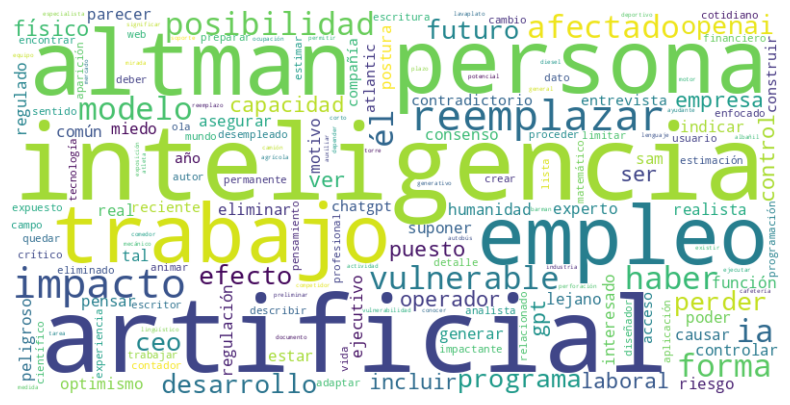

In [10]:
# Nube de palabras
crear_nube_palabras(analizador.doc)

# Gráfico de entidades
visualizar_entidades_mas_comunes(analizador.obtener_entidades())

## Parte 4: integración en un pipeline (10 minutos)

**Objetivo:** integrar extracción, análisis y reporte agregado para varias noticias.

En esta parte conviene trabajar de menor a mayor:
1. probá con una sola URL;
2. verificá que el texto se extraiga;
3. recién después procesa una lista.


In [11]:
class AnalizadorTendencias:
    def __init__(self, lista_urls):
        self.urls = lista_urls
        self.noticias_data = []
        self.analizadores = []
        self.nlp = spacy.load("es_core_news_lg")

    def procesar_todas(self):
        """Orquesta la extracción y el análisis de todas las URLs."""
        print(f"Iniciando procesamiento de {len(self.urls)} URLs...")

        for url in self.urls:
            # PASO 11: extraer la noticia
            noticia = extraer_noticia(url)

            if noticia:
                self.noticias_data.append(noticia)

                # PASO 12: crear un AnalizadorNoticia y guardarlo
                analizador = AnalizadorNoticia(noticia['texto'], self.nlp)
                self.analizadores.append(analizador)

        print("Procesamiento completado.")

    def generar_reporte_agregado(self, n=15):
        """Genera un reporte consolidado de todas las noticias procesadas."""
        if not self.analizadores:
            print("No hay noticias procesadas para generar un reporte.")
            return

        todas_las_entidades = {
            "PERSONAS": [],
            "ORGANIZACIONES": [],
            "LUGARES": [],
            "OTROS": []
        }
        todos_los_verbos = []

        # PASO 13: acumular entidades y verbos de todos los analizadores
        for analizador in self.analizadores:
            entidades = analizador.obtener_entidades()
            for tipo in todas_las_entidades:
                todas_las_entidades[tipo].extend(entidades[tipo])

            verbos = analizador.obtener_verbos_principales(n=n)
            todos_los_verbos.extend([verbo for verbo, freq in verbos])

        print(f"\n--- REPORTE AGREGADO DE {len(self.analizadores)} NOTICIAS ---")
        print("\n--- ENTIDADES MAS COMUNES ---")
        visualizar_entidades_mas_comunes(todas_las_entidades, n=n)

        print("\n--- VERBOS MAS COMUNES ---")
        frecuencias_verbos = Counter(todos_los_verbos)
        print(frecuencias_verbos.most_common(n))

In [12]:
pipeline = AnalizadorTendencias(urls_noticias)
pipeline.procesar_todas()
pipeline.generar_reporte_agregado()

Iniciando procesamiento de 1 URLs...
Procesamiento completado.

--- REPORTE AGREGADO DE 1 NOTICIAS ---

--- ENTIDADES MAS COMUNES ---



--- VERBOS MAS COMUNES ---
[('reemplazar', 1), ('perder', 1), ('incluir', 1), ('indicar', 1), ('causar', 1), ('pensar', 1), ('asegurar', 1), ('eliminar', 1), ('suponer', 1), ('controlar', 1), ('generar', 1), ('parecer', 1), ('construir', 1), ('proceder', 1), ('ver', 1)]


## Entregables, criterios de evaluación y cierre

### Entregables sugeridos
- Las funciones y clases completadas.
- Al menos una prueba con una noticia real.
- Una bitácora breve de interacción con IA.
- Una justificación corta sobre una decisión que tomaste a partir de una sugerencia de la IA y otra que descartaste.

### Criterios de evaluación
- **Funcionamiento técnico:** que el pipeline complete tareas básicas de extracción, análisis y visualización.
- **Juicio crítico:** que puedas explicar por qué elegiste una estrategia y no otra.
- **Uso de IA con criterio:** que la IA aparezca como apoyo de exploración, no como reemplazo del razonamiento.
- **Proceso documentado:** que la bitácora muestre qué tomaste, qué corregiste y qué descartaste.
- **Claridad del código:** que las funciones y clases sean legibles y consistentes.

### Checklist antes de entregar
- Probaste cada parte por separado antes de integrar todo?
- Podés explicar qué hace cada función principal?
- Tu bitácora muestra intervención humana real sobre los outputs de IA?
- Hay al menos un ejemplo donde corregiste o descartaste una sugerencia de la IA?

Si respondiste que sí a estas preguntas, tu laboratorio ya está alineado con la propuesta pedagógica de la cátedra.
